# XGBoost

## Importar Dados

In [1]:
import pandas as pd
caminho = '../'

X_test = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv')
y_train = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv')

## XGboost - Default

In [2]:
import xgboost as xgb

xgboost = xgb.XGBClassifier(n_estimators=100, random_state=14)
xgboost.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===

Acurácia: 0.7928
Precisão: 0.7673
Recall: 0.7456
F1-Score: 0.7542
MCC: 0.5124
AUC: 0.8507
--------------------------------------------------


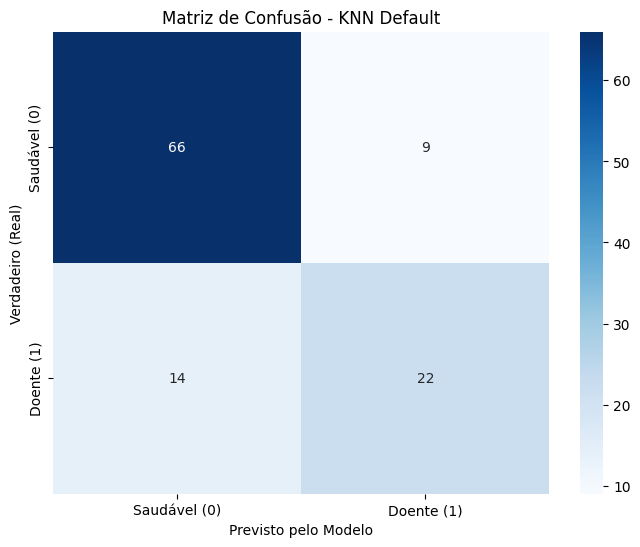

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix)

# Fazendo as Previsões no conjunto de teste
y_pred_def = xgboost.predict(X_test)
y_prob_def = xgboost.predict_proba(X_test)[:, 1]

# Métricas
acuracia_def = accuracy_score(y_test, y_pred_def)
precisao_def = precision_score(y_test, y_pred_def, average='macro', zero_division=0)
recall_def = recall_score(y_test, y_pred_def, average='macro', zero_division=0)
f1_def = f1_score(y_test, y_pred_def, average='macro', zero_division=0)
mcc_def = matthews_corrcoef(y_test, y_pred_def)
auc = roc_auc_score(y_test, y_prob_def)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===\n")
print(f"Acurácia: {acuracia_def:.4f}")
print(f"Precisão: {precisao_def:.4f}")
print(f"Recall: {recall_def:.4f}")
print(f"F1-Score: {f1_def:.4f}")
print(f"MCC: {mcc_def:.4f}")
print(f"AUC: {auc:.4f}")
print("-" * 50)

# Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_def)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])
plt.title('Matriz de Confusão - KNN Default')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## XGBoost - Melhorado

In [5]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score

def objective(trial):
    # Hiperparâmetros recomendados para XGBoost
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'objective': 'binary:logistic',
        'eval_metric': 'mlogloss',
        'n_jobs': -1,
        'random_state': 14
    }

    # Inicializa o classificador
    clf = xgb.XGBClassifier(**params)

    # Cross-validation
    score = cross_val_score(clf, X_train, y_train.values.ravel(), scoring='accuracy', cv=5).mean()
    return score

# Criando e executando
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Melhor pontuação: {study.best_value:.4f}")
print("Melhores parâmetros:")
print(study.best_params)

# Treinando o modelo final com os melhores parâmetros encontrados
best_xgb = xgb.XGBClassifier(**study.best_params, objective='binary:logistic', n_jobs=-1, random_state=14)
best_xgb.fit(X_train, y_train.values.ravel())

c:\Users\renan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-14 17:20:51,527] A new study created in memory with name: no-name-1ec0791c-98a7-4393-95d3-d47f19a6c17a
Best trial: 0. Best value: 0.790875:   2%|▏         | 1/50 [00:00<00:15,  3.17it/s]

[I 2026-08-14 17:20:51,841] Trial 0 finished with value: 0.7908748114630466 and parameters: {'n_estimators': 199, 'max_depth': 10, 'learning_rate': 0.051504486473712814, 'subsample': 0.612773323325826, 'colsample_bytree': 0.8313418079348197, 'gamma': 4.205688504399189}. Best is trial 0 with value: 0.7908748114630466.


Best trial: 1. Best value: 0.794646:   4%|▍         | 2/50 [00:00<00:17,  2.72it/s]

[I 2026-08-14 17:20:52,243] Trial 1 finished with value: 0.7946455505279035 and parameters: {'n_estimators': 207, 'max_depth': 9, 'learning_rate': 0.10174235667553322, 'subsample': 0.5081610234528589, 'colsample_bytree': 0.7111078570840621, 'gamma': 2.8661501234771385}. Best is trial 1 with value: 0.7946455505279035.


Best trial: 1. Best value: 0.794646:   6%|▌         | 3/50 [00:01<00:16,  2.79it/s]

[I 2026-08-14 17:20:52,580] Trial 2 finished with value: 0.7870286576168928 and parameters: {'n_estimators': 86, 'max_depth': 3, 'learning_rate': 0.0507154411175049, 'subsample': 0.589737387241067, 'colsample_bytree': 0.7481247940381446, 'gamma': 2.881397558733659}. Best is trial 1 with value: 0.7946455505279035.


Best trial: 1. Best value: 0.794646:   8%|▊         | 4/50 [00:01<00:17,  2.57it/s]

[I 2026-08-14 17:20:53,030] Trial 3 finished with value: 0.7946455505279035 and parameters: {'n_estimators': 254, 'max_depth': 7, 'learning_rate': 0.053938985483704315, 'subsample': 0.5214608613347238, 'colsample_bytree': 0.5510043115186076, 'gamma': 2.0360374930795673}. Best is trial 1 with value: 0.7946455505279035.


Best trial: 1. Best value: 0.794646:  10%|█         | 5/50 [00:01<00:18,  2.45it/s]

[I 2026-08-14 17:20:53,465] Trial 4 finished with value: 0.7869532428355959 and parameters: {'n_estimators': 299, 'max_depth': 9, 'learning_rate': 0.15569683242622456, 'subsample': 0.9022143318308022, 'colsample_bytree': 0.7824157472253711, 'gamma': 1.6920761611963775}. Best is trial 1 with value: 0.7946455505279035.


Best trial: 1. Best value: 0.794646:  12%|█▏        | 6/50 [00:02<00:17,  2.54it/s]

[I 2026-08-14 17:20:53,833] Trial 5 finished with value: 0.7908748114630466 and parameters: {'n_estimators': 238, 'max_depth': 7, 'learning_rate': 0.09419029636775415, 'subsample': 0.837668215872628, 'colsample_bytree': 0.879283688588756, 'gamma': 2.7813412122880092}. Best is trial 1 with value: 0.7946455505279035.


Best trial: 6. Best value: 0.798567:  14%|█▍        | 7/50 [00:02<00:14,  2.92it/s]

[I 2026-08-14 17:20:54,069] Trial 6 finished with value: 0.7985671191553545 and parameters: {'n_estimators': 115, 'max_depth': 7, 'learning_rate': 0.14834844675929706, 'subsample': 0.9447875364606877, 'colsample_bytree': 0.9499005912912559, 'gamma': 2.5012919234636266}. Best is trial 6 with value: 0.7985671191553545.


Best trial: 6. Best value: 0.798567:  16%|█▌        | 8/50 [00:02<00:13,  3.06it/s]

[I 2026-08-14 17:20:54,362] Trial 7 finished with value: 0.7792609351432881 and parameters: {'n_estimators': 168, 'max_depth': 8, 'learning_rate': 0.13170331293922416, 'subsample': 0.5948751290261605, 'colsample_bytree': 0.8362190948481456, 'gamma': 2.6091400046034474}. Best is trial 6 with value: 0.7985671191553545.


Best trial: 8. Best value: 0.80641:  18%|█▊        | 9/50 [00:03<00:12,  3.21it/s] 

[I 2026-08-14 17:20:54,639] Trial 8 finished with value: 0.8064102564102564 and parameters: {'n_estimators': 81, 'max_depth': 3, 'learning_rate': 0.036558748446232685, 'subsample': 0.9388346120138245, 'colsample_bytree': 0.7411180790702224, 'gamma': 0.0016331481755382793}. Best is trial 8 with value: 0.8064102564102564.


Best trial: 8. Best value: 0.80641:  20%|██        | 10/50 [00:03<00:14,  2.79it/s]

[I 2026-08-14 17:20:55,104] Trial 9 finished with value: 0.8064102564102564 and parameters: {'n_estimators': 122, 'max_depth': 7, 'learning_rate': 0.01680306987148387, 'subsample': 0.6275989669718944, 'colsample_bytree': 0.8361957049897064, 'gamma': 0.564272207014534}. Best is trial 8 with value: 0.8064102564102564.


Best trial: 8. Best value: 0.80641:  22%|██▏       | 11/50 [00:03<00:13,  2.98it/s]

[I 2026-08-14 17:20:55,388] Trial 10 finished with value: 0.8024132730015083 and parameters: {'n_estimators': 64, 'max_depth': 3, 'learning_rate': 0.01874293099898214, 'subsample': 0.7565920192094798, 'colsample_bytree': 0.6315074493674905, 'gamma': 0.05732421919544439}. Best is trial 8 with value: 0.8064102564102564.


Best trial: 8. Best value: 0.80641:  24%|██▍       | 12/50 [00:04<00:14,  2.54it/s]

[I 2026-08-14 17:20:55,912] Trial 11 finished with value: 0.7946455505279035 and parameters: {'n_estimators': 132, 'max_depth': 5, 'learning_rate': 0.015055603654768887, 'subsample': 0.7079068238528045, 'colsample_bytree': 0.6728085517045567, 'gamma': 0.0949896355783747}. Best is trial 8 with value: 0.8064102564102564.


Best trial: 8. Best value: 0.80641:  26%|██▌       | 13/50 [00:04<00:15,  2.37it/s]

[I 2026-08-14 17:20:56,398] Trial 12 finished with value: 0.7985671191553545 and parameters: {'n_estimators': 123, 'max_depth': 5, 'learning_rate': 0.023871764277806726, 'subsample': 0.7165145416817864, 'colsample_bytree': 0.9902577826994691, 'gamma': 0.8544672846704908}. Best is trial 8 with value: 0.8064102564102564.


Best trial: 8. Best value: 0.80641:  28%|██▊       | 14/50 [00:05<00:13,  2.65it/s]

[I 2026-08-14 17:20:56,673] Trial 13 finished with value: 0.7518853695324283 and parameters: {'n_estimators': 52, 'max_depth': 5, 'learning_rate': 0.010504738966690278, 'subsample': 0.9940343580447961, 'colsample_bytree': 0.9113437716690896, 'gamma': 0.8630087700099982}. Best is trial 8 with value: 0.8064102564102564.


Best trial: 14. Best value: 0.810106:  30%|███       | 15/50 [00:05<00:13,  2.59it/s]

[I 2026-08-14 17:20:57,080] Trial 14 finished with value: 0.810105580693816 and parameters: {'n_estimators': 152, 'max_depth': 4, 'learning_rate': 0.028216398528370056, 'subsample': 0.8152302503380298, 'colsample_bytree': 0.5753233056756363, 'gamma': 0.9406636945015703}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  32%|███▏      | 16/50 [00:05<00:12,  2.79it/s]

[I 2026-08-14 17:20:57,376] Trial 15 finished with value: 0.7907993966817497 and parameters: {'n_estimators': 160, 'max_depth': 4, 'learning_rate': 0.2911301867230259, 'subsample': 0.8404369435140532, 'colsample_bytree': 0.5222213119904853, 'gamma': 1.5354528203714084}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  34%|███▍      | 17/50 [00:06<00:11,  2.89it/s]

[I 2026-08-14 17:20:57,691] Trial 16 finished with value: 0.7947209653092007 and parameters: {'n_estimators': 91, 'max_depth': 4, 'learning_rate': 0.03182372393866568, 'subsample': 0.8273307822493694, 'colsample_bytree': 0.6145937667430723, 'gamma': 3.9552145095722757}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  36%|███▌      | 18/50 [00:06<00:11,  2.71it/s]

[I 2026-08-14 17:20:58,114] Trial 17 finished with value: 0.8025641025641026 and parameters: {'n_estimators': 152, 'max_depth': 4, 'learning_rate': 0.034139074847896175, 'subsample': 0.8975204219041102, 'colsample_bytree': 0.5972423013008851, 'gamma': 1.3676956809429086}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  38%|███▊      | 19/50 [00:06<00:11,  2.67it/s]

[I 2026-08-14 17:20:58,499] Trial 18 finished with value: 0.7947963800904978 and parameters: {'n_estimators': 198, 'max_depth': 3, 'learning_rate': 0.03477344510137022, 'subsample': 0.7724443736198472, 'colsample_bytree': 0.6824622183781884, 'gamma': 4.826594468776044}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  40%|████      | 20/50 [00:07<00:11,  2.54it/s]

[I 2026-08-14 17:20:58,941] Trial 19 finished with value: 0.7868778280542987 and parameters: {'n_estimators': 90, 'max_depth': 6, 'learning_rate': 0.07748853684702156, 'subsample': 0.987304576444173, 'colsample_bytree': 0.5055949019829152, 'gamma': 0.5988749176717126}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  42%|████▏     | 21/50 [00:07<00:11,  2.47it/s]

[I 2026-08-14 17:20:59,372] Trial 20 finished with value: 0.7947963800904976 and parameters: {'n_estimators': 145, 'max_depth': 4, 'learning_rate': 0.025290697515653042, 'subsample': 0.9057231356356403, 'colsample_bytree': 0.5739617405235509, 'gamma': 1.1521861159576121}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  44%|████▍     | 22/50 [00:08<00:11,  2.37it/s]

[I 2026-08-14 17:20:59,831] Trial 21 finished with value: 0.7985671191553545 and parameters: {'n_estimators': 122, 'max_depth': 6, 'learning_rate': 0.01301987056496536, 'subsample': 0.6473906232217714, 'colsample_bytree': 0.785206529698083, 'gamma': 0.37861439892127735}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  46%|████▌     | 23/50 [00:08<00:11,  2.28it/s]

[I 2026-08-14 17:21:00,309] Trial 22 finished with value: 0.7869532428355959 and parameters: {'n_estimators': 105, 'max_depth': 8, 'learning_rate': 0.019842680744860435, 'subsample': 0.6717343529042042, 'colsample_bytree': 0.8349417067647525, 'gamma': 0.6514571296228402}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  48%|████▊     | 24/50 [00:09<00:12,  2.10it/s]

[I 2026-08-14 17:21:00,869] Trial 23 finished with value: 0.8024886877828055 and parameters: {'n_estimators': 182, 'max_depth': 6, 'learning_rate': 0.04016760784333803, 'subsample': 0.7952619054206541, 'colsample_bytree': 0.7246087210782182, 'gamma': 0.0004747500458932574}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  50%|█████     | 25/50 [00:09<00:10,  2.50it/s]

[I 2026-08-14 17:21:01,096] Trial 24 finished with value: 0.7908748114630466 and parameters: {'n_estimators': 74, 'max_depth': 3, 'learning_rate': 0.024465114477510697, 'subsample': 0.9407862625761114, 'colsample_bytree': 0.781233274393199, 'gamma': 1.9566281023065868}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  52%|█████▏    | 26/50 [00:10<00:09,  2.44it/s]

[I 2026-08-14 17:21:01,531] Trial 25 finished with value: 0.810105580693816 and parameters: {'n_estimators': 140, 'max_depth': 5, 'learning_rate': 0.01605045230801864, 'subsample': 0.7119185879842166, 'colsample_bytree': 0.6623908500806861, 'gamma': 1.1708929744888386}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  54%|█████▍    | 27/50 [00:10<00:10,  2.28it/s]

[I 2026-08-14 17:21:02,034] Trial 26 finished with value: 0.7985671191553545 and parameters: {'n_estimators': 180, 'max_depth': 5, 'learning_rate': 0.010010772928294196, 'subsample': 0.7239355511733901, 'colsample_bytree': 0.662699301919437, 'gamma': 1.1545071867880854}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  56%|█████▌    | 28/50 [00:10<00:09,  2.35it/s]

[I 2026-08-14 17:21:02,430] Trial 27 finished with value: 0.8064856711915536 and parameters: {'n_estimators': 220, 'max_depth': 4, 'learning_rate': 0.06533822610570057, 'subsample': 0.873646729093714, 'colsample_bytree': 0.6343067152552523, 'gamma': 2.1192612712621806}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  58%|█████▊    | 29/50 [00:11<00:08,  2.35it/s]

[I 2026-08-14 17:21:02,859] Trial 28 finished with value: 0.7986425339366516 and parameters: {'n_estimators': 226, 'max_depth': 4, 'learning_rate': 0.07329958236009503, 'subsample': 0.7977156119744184, 'colsample_bytree': 0.6376771715933374, 'gamma': 2.2258148154869564}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  60%|██████    | 30/50 [00:11<00:08,  2.32it/s]

[I 2026-08-14 17:21:03,296] Trial 29 finished with value: 0.8024132730015083 and parameters: {'n_estimators': 275, 'max_depth': 5, 'learning_rate': 0.06542177999631196, 'subsample': 0.8736508160819942, 'colsample_bytree': 0.5507805472292572, 'gamma': 3.5149171953923677}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  62%|██████▏   | 31/50 [00:12<00:08,  2.27it/s]

[I 2026-08-14 17:21:03,764] Trial 30 finished with value: 0.7985671191553545 and parameters: {'n_estimators': 204, 'max_depth': 4, 'learning_rate': 0.043924218852601865, 'subsample': 0.6766277489553703, 'colsample_bytree': 0.5893245065113053, 'gamma': 3.242115799427879}. Best is trial 14 with value: 0.810105580693816.


Best trial: 14. Best value: 0.810106:  64%|██████▍   | 32/50 [00:12<00:07,  2.35it/s]

[I 2026-08-14 17:21:04,156] Trial 31 finished with value: 0.8025641025641026 and parameters: {'n_estimators': 137, 'max_depth': 3, 'learning_rate': 0.029880430172635915, 'subsample': 0.9370980623593971, 'colsample_bytree': 0.6972968038806849, 'gamma': 1.1142066405631852}. Best is trial 14 with value: 0.810105580693816.


Best trial: 32. Best value: 0.814103:  66%|██████▌   | 33/50 [00:13<00:07,  2.37it/s]

[I 2026-08-14 17:21:04,568] Trial 32 finished with value: 0.8141025641025641 and parameters: {'n_estimators': 222, 'max_depth': 4, 'learning_rate': 0.04341734573042893, 'subsample': 0.8674139101239593, 'colsample_bytree': 0.6462069844549037, 'gamma': 1.733975424595677}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  68%|██████▊   | 34/50 [00:13<00:06,  2.37it/s]

[I 2026-08-14 17:21:04,991] Trial 33 finished with value: 0.8141025641025641 and parameters: {'n_estimators': 219, 'max_depth': 5, 'learning_rate': 0.048251854666547675, 'subsample': 0.8600244180250354, 'colsample_bytree': 0.6475600300808589, 'gamma': 1.869335694446074}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  70%|███████   | 35/50 [00:13<00:06,  2.38it/s]

[I 2026-08-14 17:21:05,409] Trial 34 finished with value: 0.8063348416289593 and parameters: {'n_estimators': 189, 'max_depth': 5, 'learning_rate': 0.05074353414624358, 'subsample': 0.7987390964792944, 'colsample_bytree': 0.5661193223324539, 'gamma': 1.759331298862847}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  72%|███████▏  | 36/50 [00:14<00:06,  2.18it/s]

[I 2026-08-14 17:21:05,952] Trial 35 finished with value: 0.8103318250377074 and parameters: {'n_estimators': 252, 'max_depth': 6, 'learning_rate': 0.04544472489152581, 'subsample': 0.86133247713042, 'colsample_bytree': 0.6543525281730569, 'gamma': 1.455029381512895}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  74%|███████▍  | 37/50 [00:15<00:06,  2.03it/s]

[I 2026-08-14 17:21:06,526] Trial 36 finished with value: 0.8062594268476622 and parameters: {'n_estimators': 258, 'max_depth': 6, 'learning_rate': 0.04679168927030847, 'subsample': 0.8592133758724948, 'colsample_bytree': 0.5374861132269843, 'gamma': 1.7729260094728858}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  76%|███████▌  | 38/50 [00:15<00:05,  2.09it/s]

[I 2026-08-14 17:21:06,976] Trial 37 finished with value: 0.8062594268476622 and parameters: {'n_estimators': 241, 'max_depth': 6, 'learning_rate': 0.09991168286909483, 'subsample': 0.8287124998775209, 'colsample_bytree': 0.7071076180425149, 'gamma': 2.2724213479191815}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  78%|███████▊  | 39/50 [00:15<00:05,  2.06it/s]

[I 2026-08-14 17:21:07,473] Trial 38 finished with value: 0.814027149321267 and parameters: {'n_estimators': 290, 'max_depth': 8, 'learning_rate': 0.05893422234870513, 'subsample': 0.8893396974564002, 'colsample_bytree': 0.6060265655044725, 'gamma': 1.461190655242664}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  80%|████████  | 40/50 [00:16<00:05,  2.00it/s]

[I 2026-08-14 17:21:08,006] Trial 39 finished with value: 0.8063348416289593 and parameters: {'n_estimators': 299, 'max_depth': 8, 'learning_rate': 0.05779247021339769, 'subsample': 0.9055998639399051, 'colsample_bytree': 0.6130928437134259, 'gamma': 1.5766415272085004}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  82%|████████▏ | 41/50 [00:16<00:04,  2.02it/s]

[I 2026-08-14 17:21:08,487] Trial 40 finished with value: 0.7830316742081449 and parameters: {'n_estimators': 278, 'max_depth': 9, 'learning_rate': 0.08480612341025058, 'subsample': 0.5457120025502538, 'colsample_bytree': 0.6502929313311314, 'gamma': 2.8940149884891224}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  84%|████████▍ | 42/50 [00:17<00:04,  1.89it/s]

[I 2026-08-14 17:21:09,103] Trial 41 finished with value: 0.8102564102564103 and parameters: {'n_estimators': 270, 'max_depth': 9, 'learning_rate': 0.05733175033427663, 'subsample': 0.860981075944188, 'colsample_bytree': 0.5953170452614378, 'gamma': 1.4112769674314922}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  86%|████████▌ | 43/50 [00:18<00:03,  1.99it/s]

[I 2026-08-14 17:21:09,537] Trial 42 finished with value: 0.8064102564102564 and parameters: {'n_estimators': 263, 'max_depth': 10, 'learning_rate': 0.12221350700170264, 'subsample': 0.860756857202714, 'colsample_bytree': 0.6046377470808493, 'gamma': 1.42945576122511}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  88%|████████▊ | 44/50 [00:18<00:03,  1.85it/s]

[I 2026-08-14 17:21:10,171] Trial 43 finished with value: 0.8102564102564103 and parameters: {'n_estimators': 282, 'max_depth': 9, 'learning_rate': 0.05932301132429624, 'subsample': 0.8901579007022463, 'colsample_bytree': 0.6235483193428392, 'gamma': 1.9236137529240636}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  90%|█████████ | 45/50 [00:19<00:02,  1.98it/s]

[I 2026-08-14 17:21:10,591] Trial 44 finished with value: 0.7907993966817497 and parameters: {'n_estimators': 244, 'max_depth': 8, 'learning_rate': 0.04328555681801693, 'subsample': 0.9613954395651484, 'colsample_bytree': 0.7365741294556312, 'gamma': 2.295458730747511}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  92%|█████████▏| 46/50 [00:19<00:01,  2.05it/s]

[I 2026-08-14 17:21:11,042] Trial 45 finished with value: 0.7947209653092007 and parameters: {'n_estimators': 221, 'max_depth': 10, 'learning_rate': 0.05220837350146985, 'subsample': 0.9215460911361141, 'colsample_bytree': 0.6883080012195641, 'gamma': 2.605651127633661}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  94%|█████████▍| 47/50 [00:20<00:01,  2.01it/s]

[I 2026-08-14 17:21:11,558] Trial 46 finished with value: 0.8025641025641026 and parameters: {'n_estimators': 287, 'max_depth': 7, 'learning_rate': 0.03880476311290576, 'subsample': 0.8509288407471525, 'colsample_bytree': 0.6474471797501138, 'gamma': 1.3461789763541094}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  96%|█████████▌| 48/50 [00:20<00:00,  2.09it/s]

[I 2026-08-14 17:21:11,995] Trial 47 finished with value: 0.8024132730015083 and parameters: {'n_estimators': 253, 'max_depth': 9, 'learning_rate': 0.06665932964231747, 'subsample': 0.7652966273652521, 'colsample_bytree': 0.7648929126421011, 'gamma': 1.778984677248709}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103:  98%|█████████▊| 49/50 [00:20<00:00,  2.15it/s]

[I 2026-08-14 17:21:12,429] Trial 48 finished with value: 0.7948717948717949 and parameters: {'n_estimators': 231, 'max_depth': 9, 'learning_rate': 0.08905353289777573, 'subsample': 0.9653611473764139, 'colsample_bytree': 0.589846357289038, 'gamma': 2.387700659090162}. Best is trial 32 with value: 0.8141025641025641.


Best trial: 32. Best value: 0.814103: 100%|██████████| 50/50 [00:21<00:00,  2.35it/s]

[I 2026-08-14 17:21:12,812] Trial 49 finished with value: 0.779260935143288 and parameters: {'n_estimators': 214, 'max_depth': 7, 'learning_rate': 0.18875951180949055, 'subsample': 0.8828674354173253, 'colsample_bytree': 0.5474178873278313, 'gamma': 1.9684044945795751}. Best is trial 32 with value: 0.8141025641025641.
Melhor pontuação: 0.8141
Melhores parâmetros:
{'n_estimators': 222, 'max_depth': 4, 'learning_rate': 0.04341734573042893, 'subsample': 0.8674139101239593, 'colsample_bytree': 0.6462069844549037, 'gamma': 1.733975424595677}


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6462069844549037
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [7]:
fig = optuna.visualization.plot_param_importances(study)
fig.show()

fig = optuna.visualization.plot_optimization_history(study)
fig.show()

=== MÉTRICAS DE DESEMPENHO ===

Acurácia: 0.7928
Precisão: 0.7673
Recall:   0.7456
F1-Score: 0.7542
MCC:      0.5124
AUC:      0.8619
--------------------------------------------------


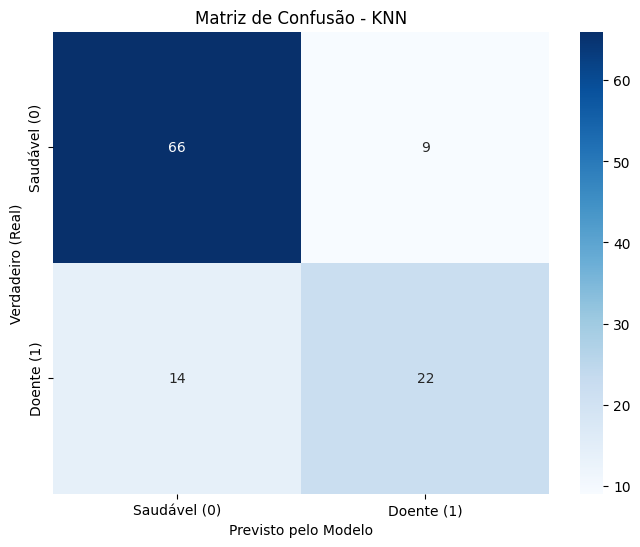

In [8]:
# Fazendo as Previsões
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

# Métricas
acuracia_best = accuracy_score(y_test, y_pred_best)
precisao_best = precision_score(y_test, y_pred_best, average='macro')
recall_best   = recall_score(y_test, y_pred_best, average='macro')
f1_best       = f1_score(y_test, y_pred_best, average='macro')
mcc_best      = matthews_corrcoef(y_test, y_pred_best)

# O AUC binário recebe as classes reais e as probabilidades diretamente
auc = roc_auc_score(y_test, y_prob_best)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO ===\n")
print(f"Acurácia: {acuracia_best:.4f}")
print(f"Precisão: {precisao_best:.4f}")
print(f"Recall:   {recall_best:.4f}")
print(f"F1-Score: {f1_best:.4f}")
print(f"MCC:      {mcc_best:.4f}")
print(f"AUC:      {auc:.4f}")
print("-" * 50)


# 5. Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)

# Labels ajustados exclusivamente para as duas doenças
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])

plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## Salvar Resultados

In [9]:
import os
import pandas as pd

nome_modelo = 'xgb'

# Caminhos dos arquivos
pasta_results = os.path.join(caminho, 'results')
os.makedirs(pasta_results, exist_ok=True)

arquivo_pred = os.path.join(pasta_results, 'predicoes.csv')
arquivo_proba = os.path.join(pasta_results, 'probabilidades.csv')

# Monta a linha com as predições de teste
linha_pred_teste = [nome_modelo, 'teste'] + list(y_pred_best)

# Salva adicionando no final do arquivo (mode='a')
pd.DataFrame([linha_pred_teste]).to_csv(
    arquivo_pred, mode='a', header=False, index=False
)

# Monta a linha com as probabilidades de teste 
probs = (
    y_prob_best[:, 1]
    if hasattr(y_prob_best, 'ndim') and y_prob_best.ndim == 2
    else y_prob_best
)
linha_proba_teste = [nome_modelo, 'teste'] + list(probs)

pd.DataFrame([linha_proba_teste]).to_csv(
    arquivo_proba, mode='a', header=False, index=False
)

print(f'Predições e probabilidades do modelo {nome_modelo} salvas com sucesso!')

Predições e probabilidades do modelo xgb salvas com sucesso!
